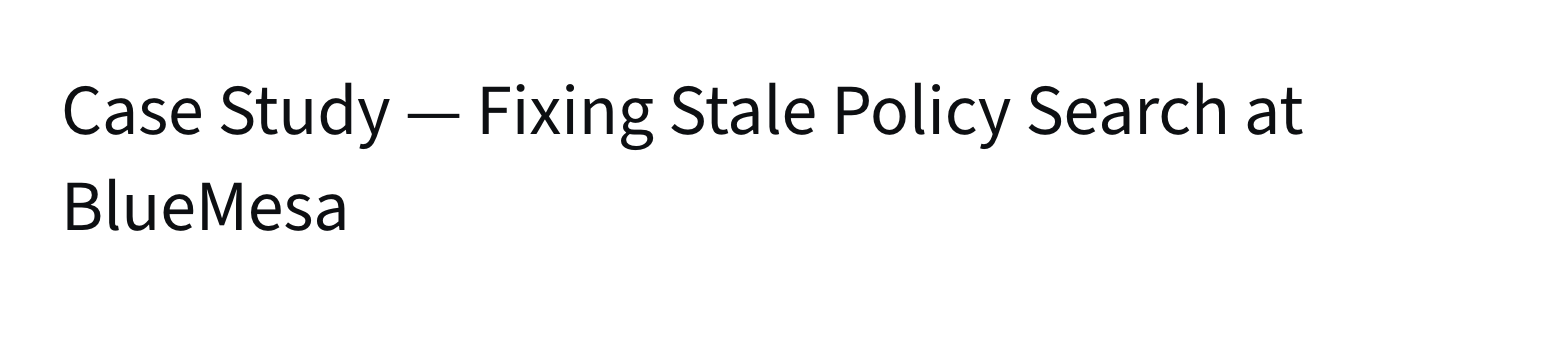

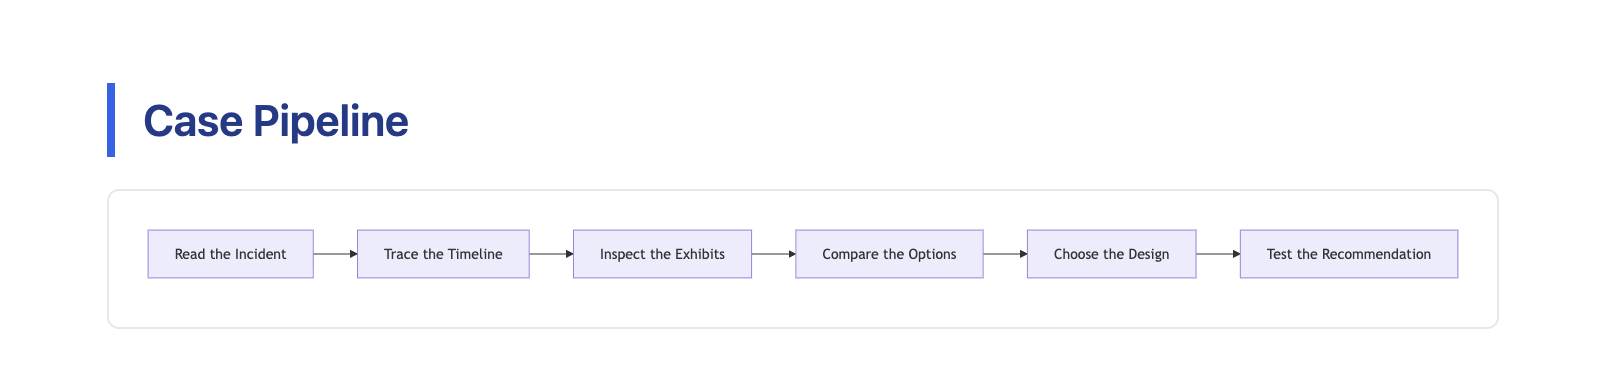

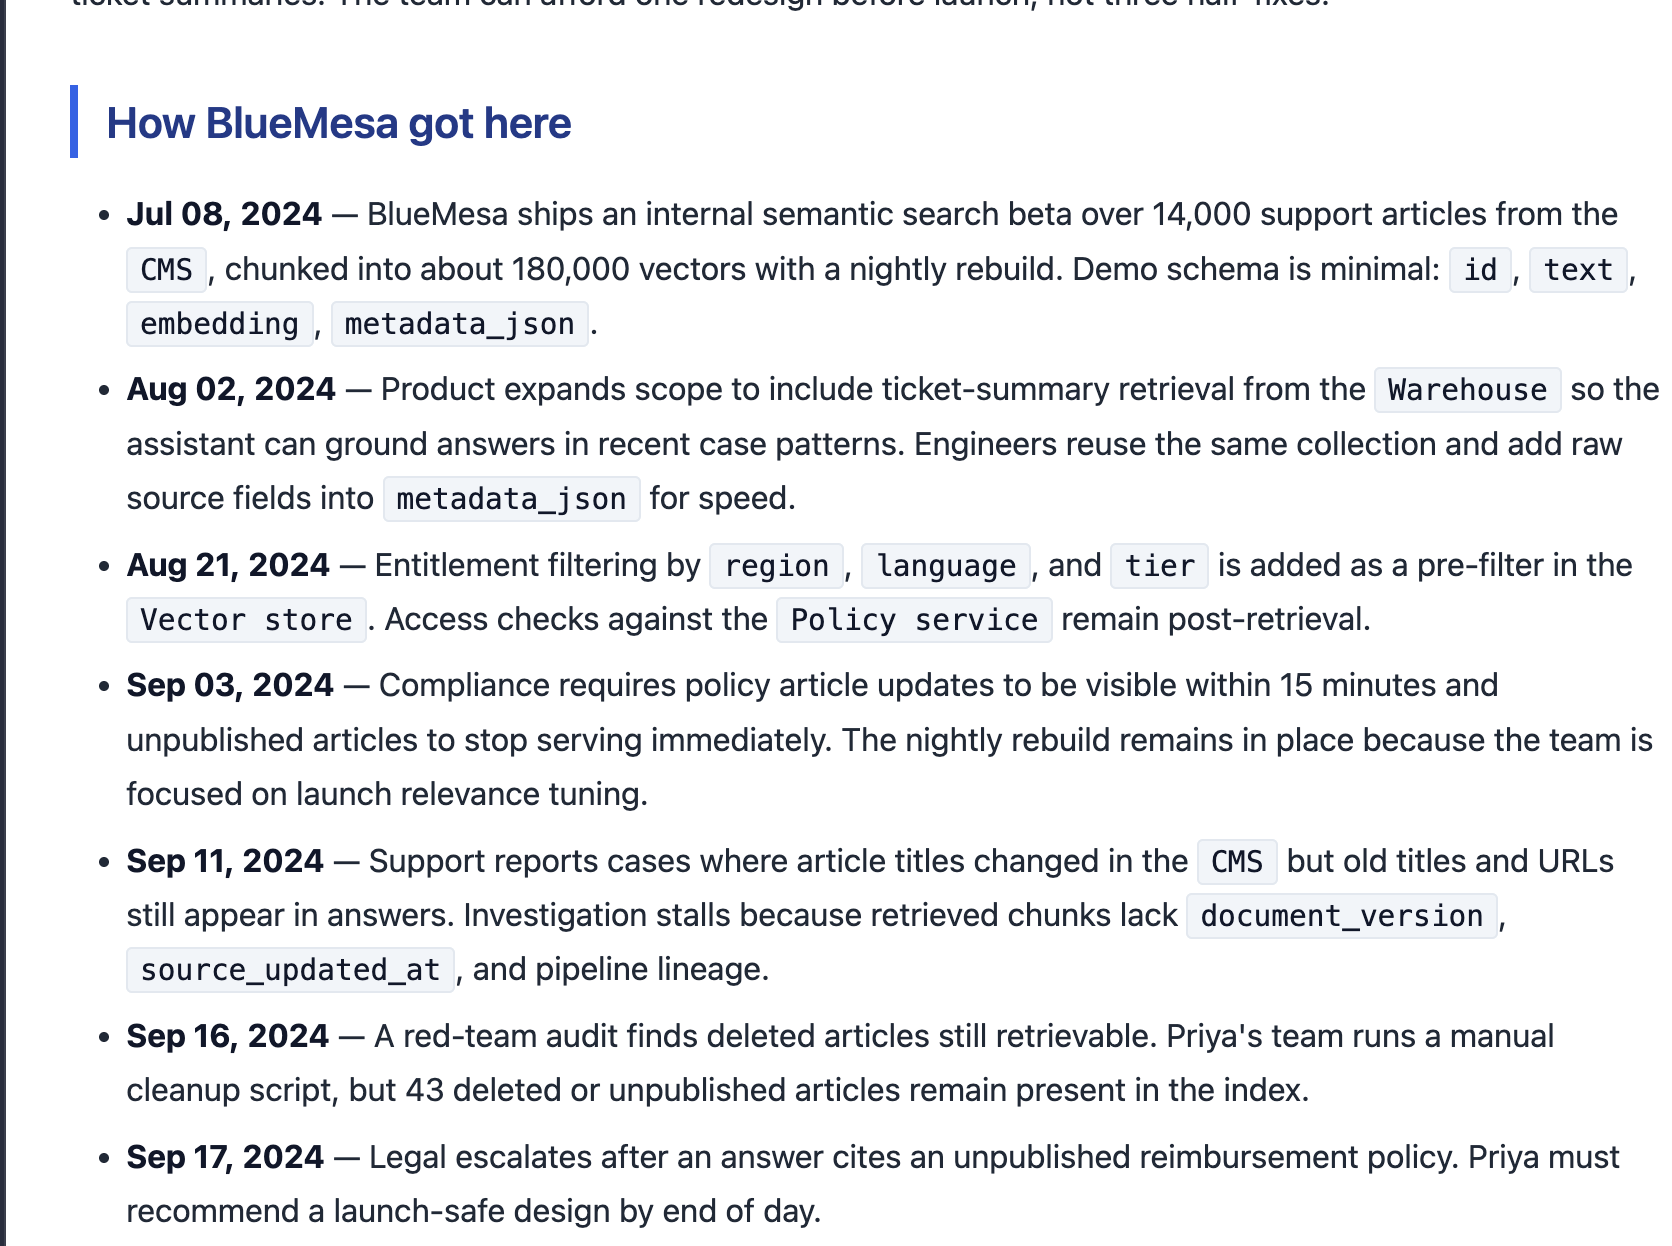
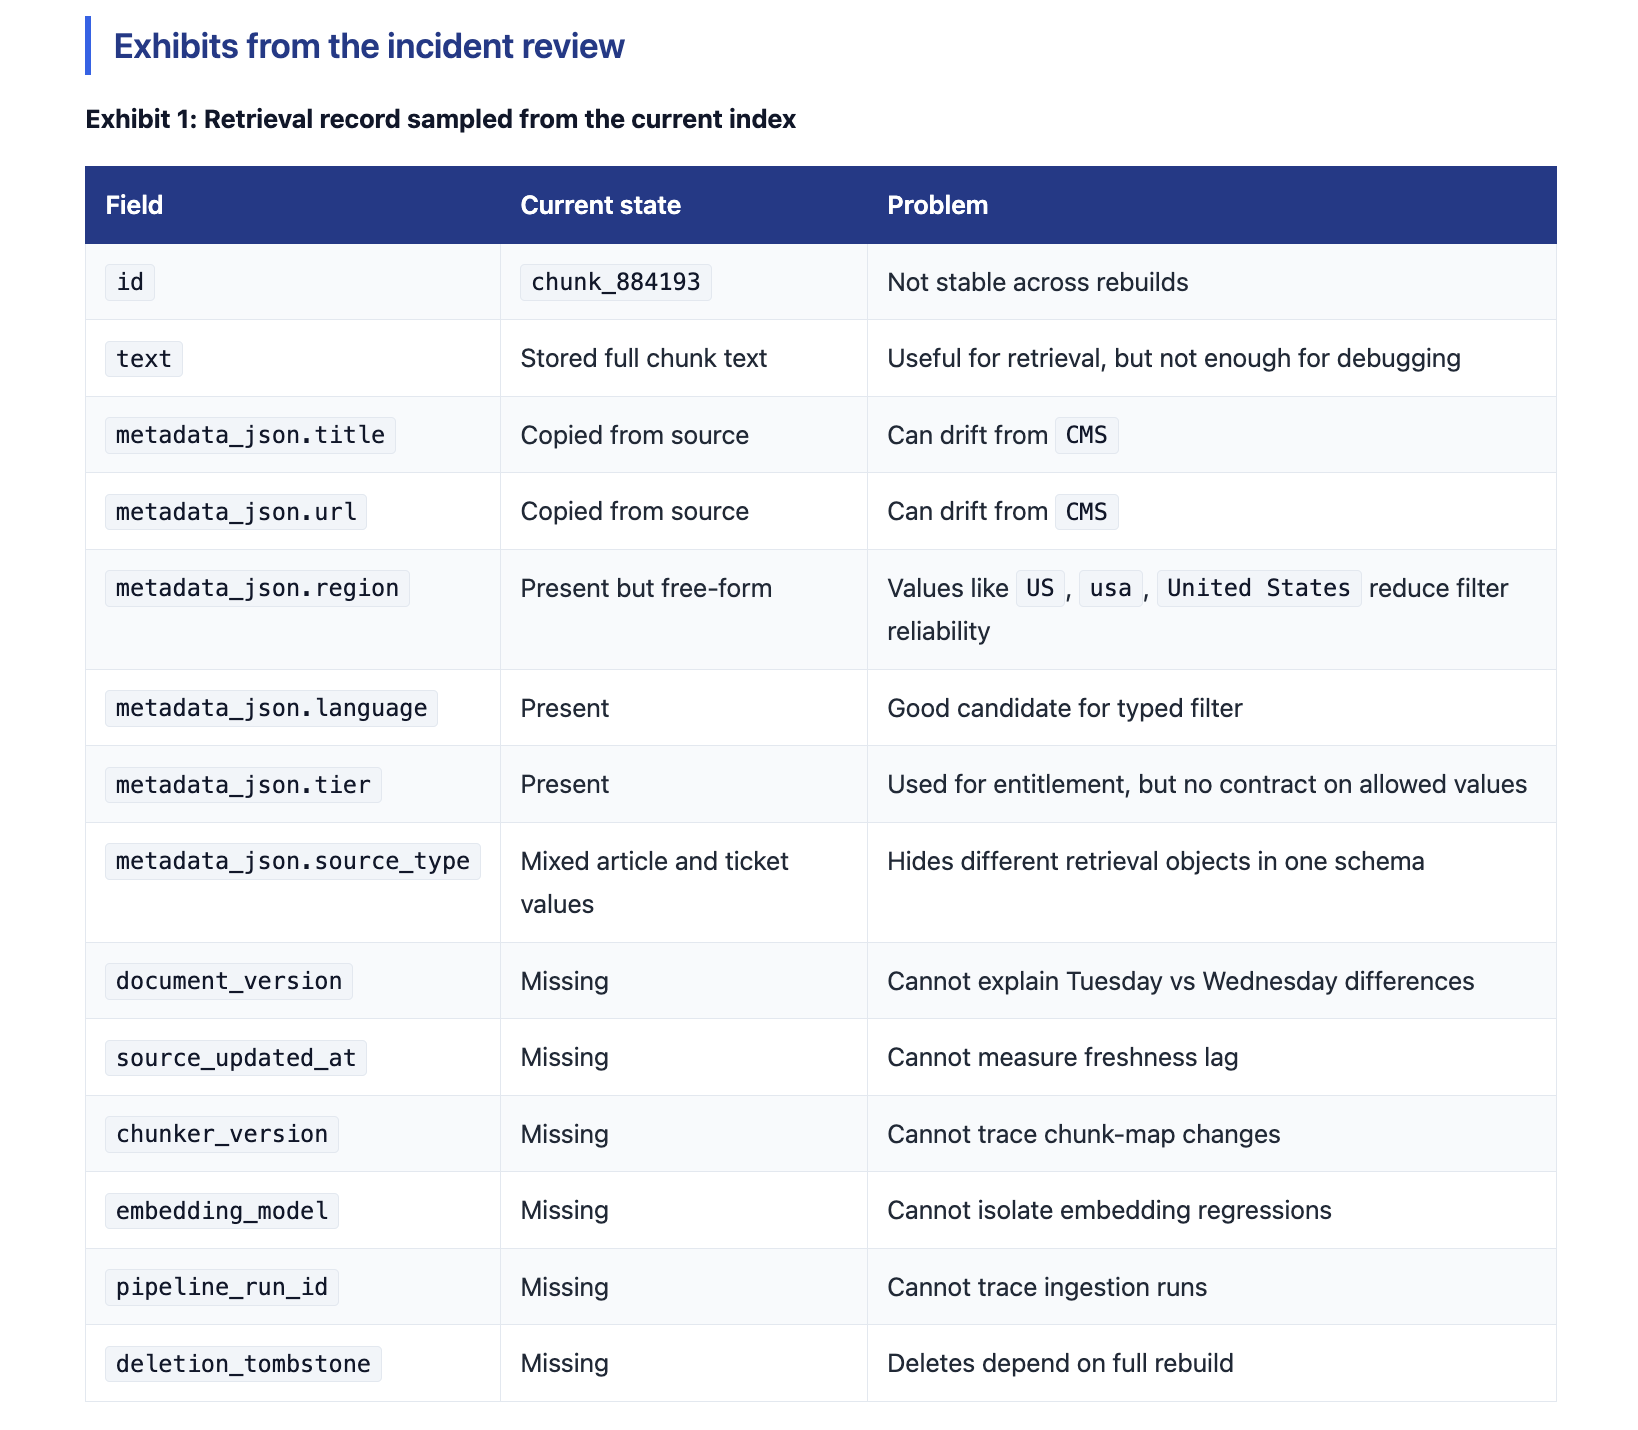
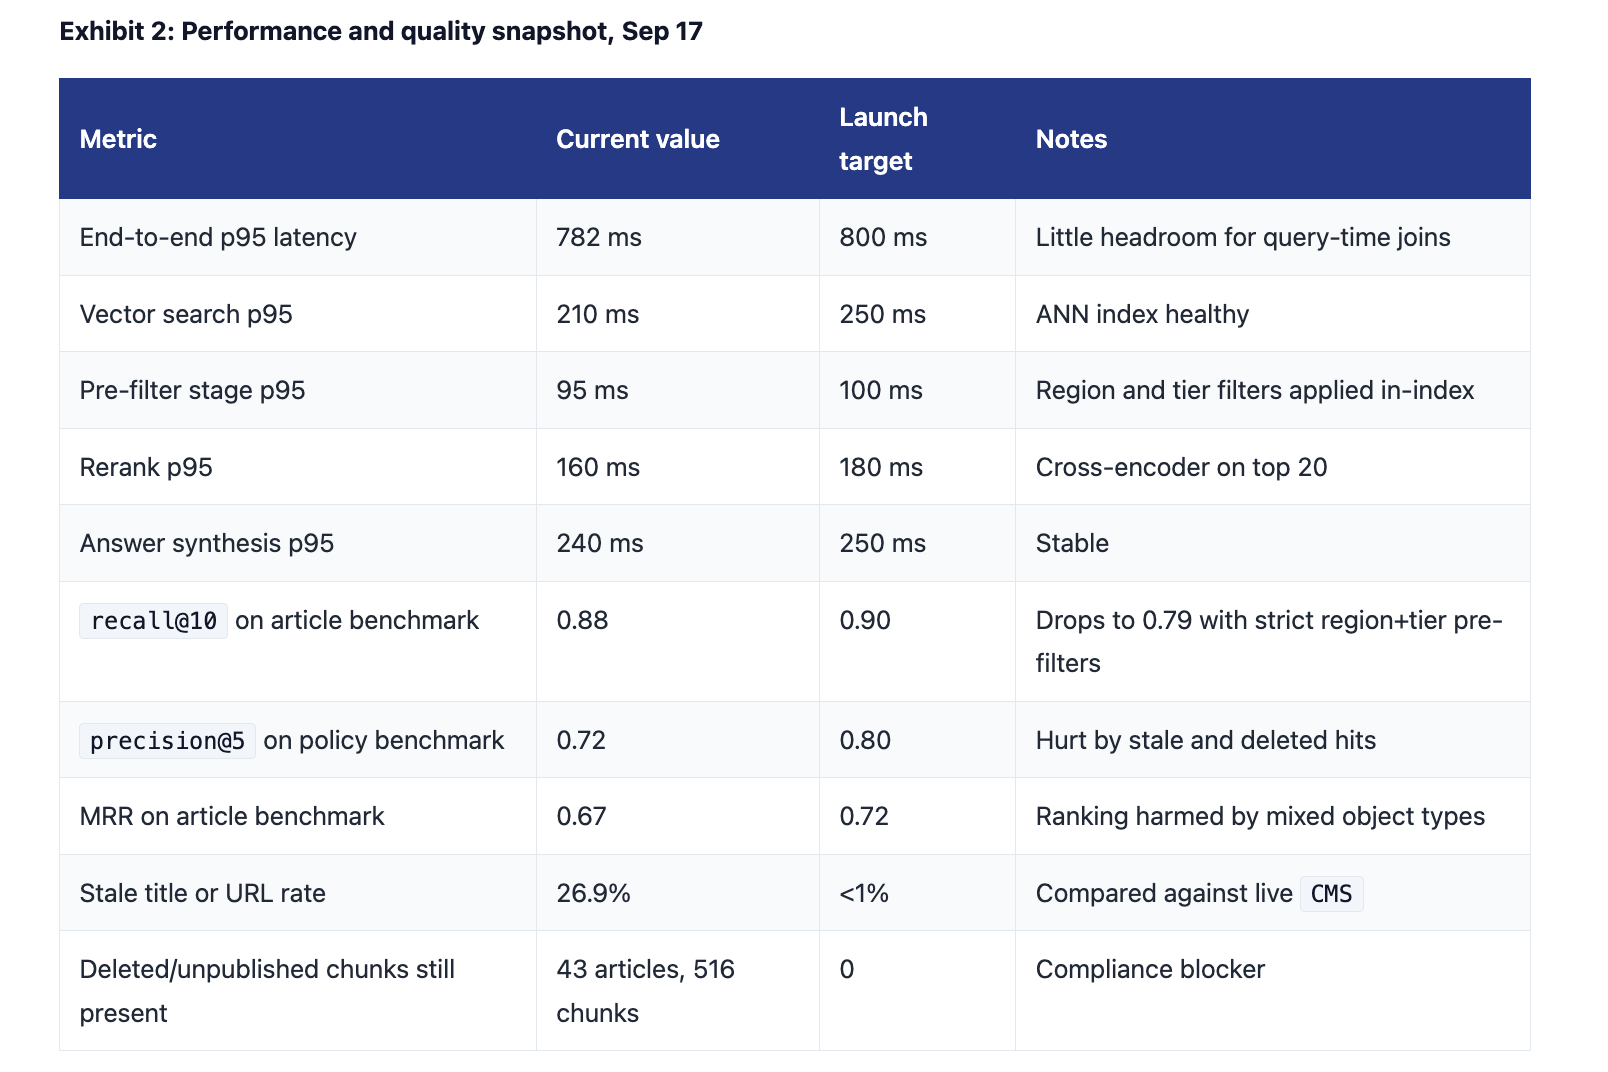
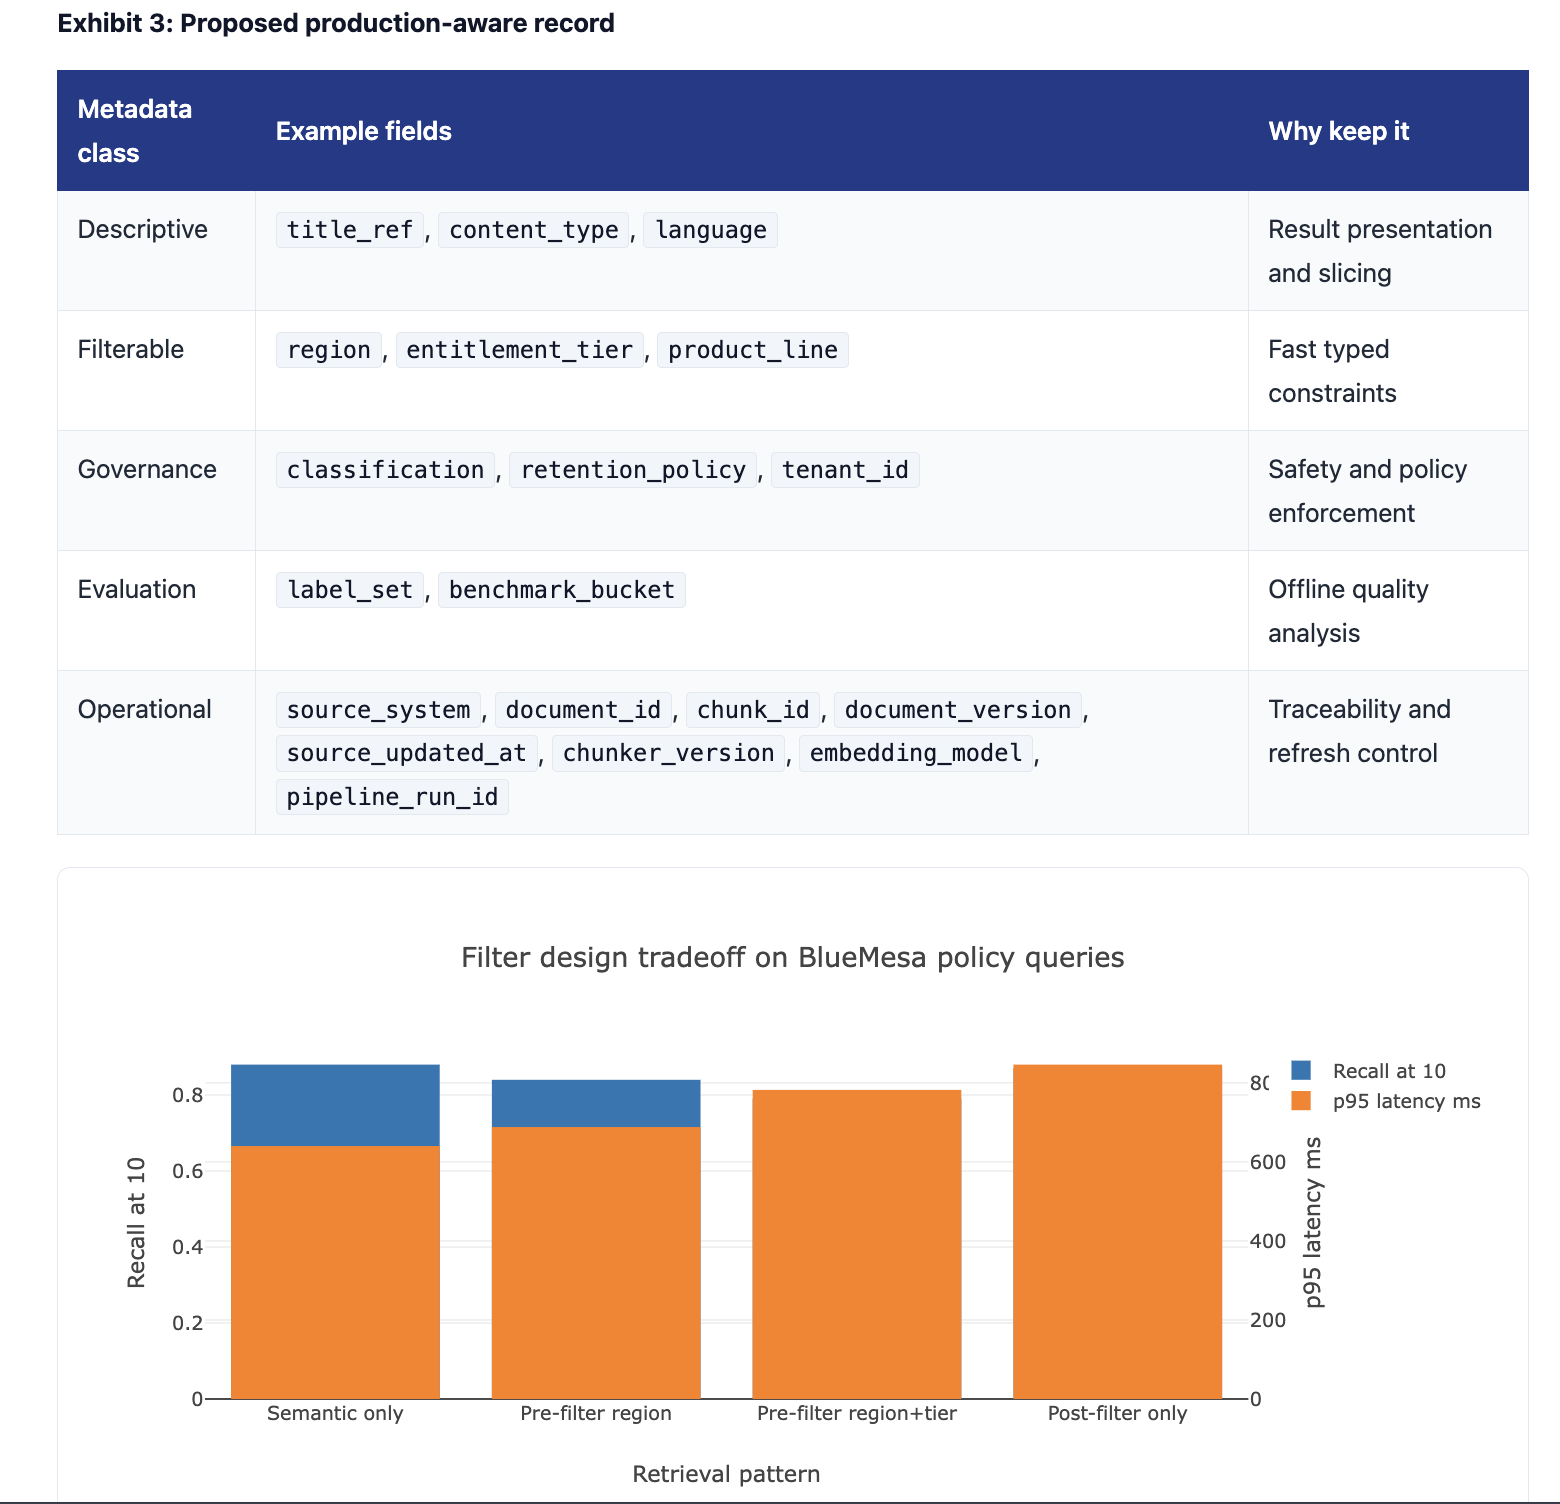
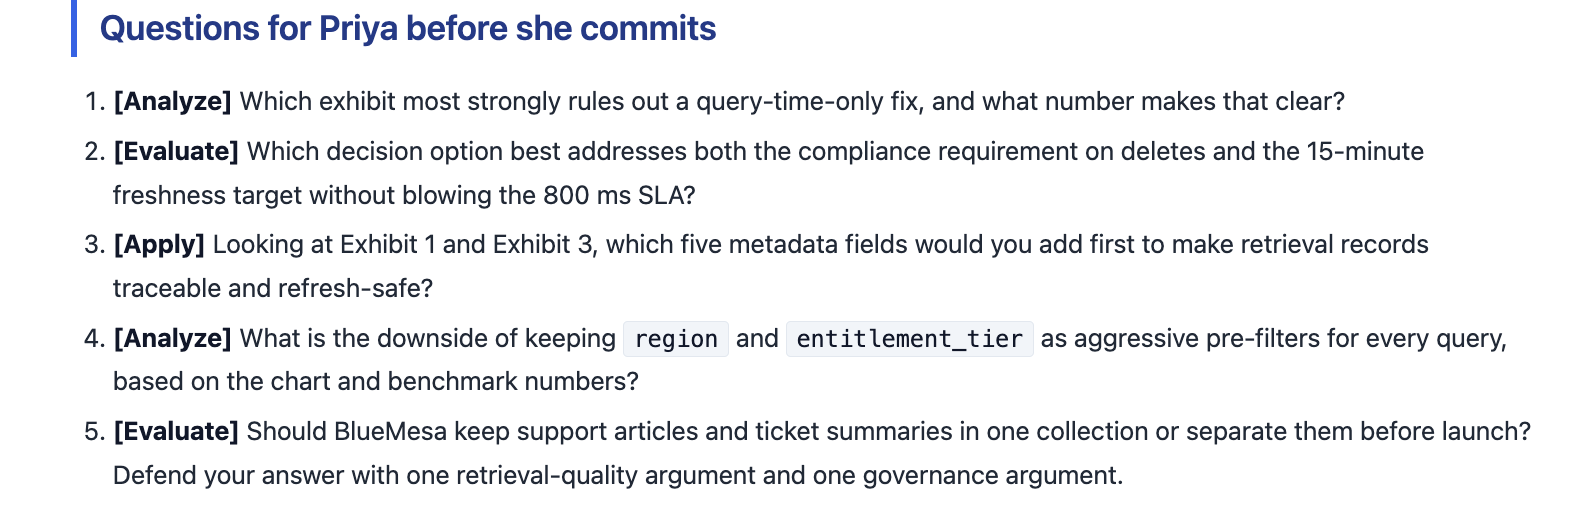
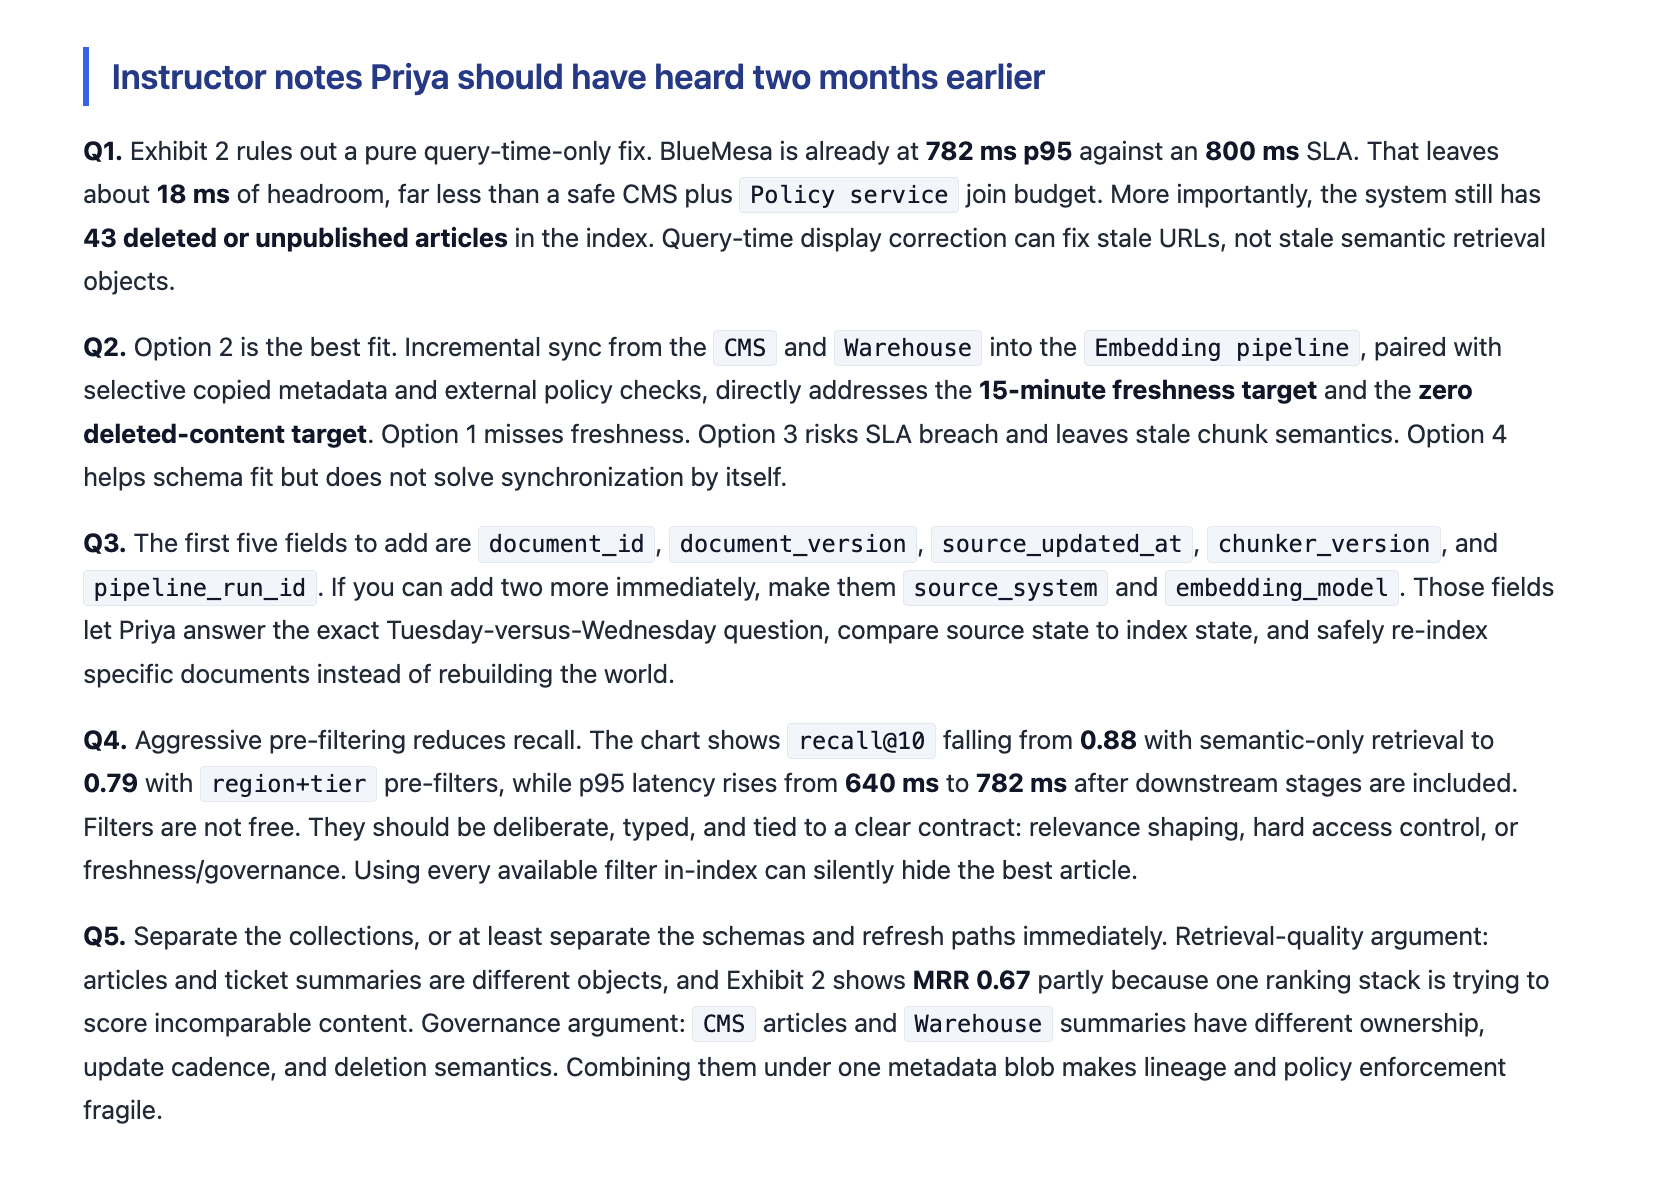
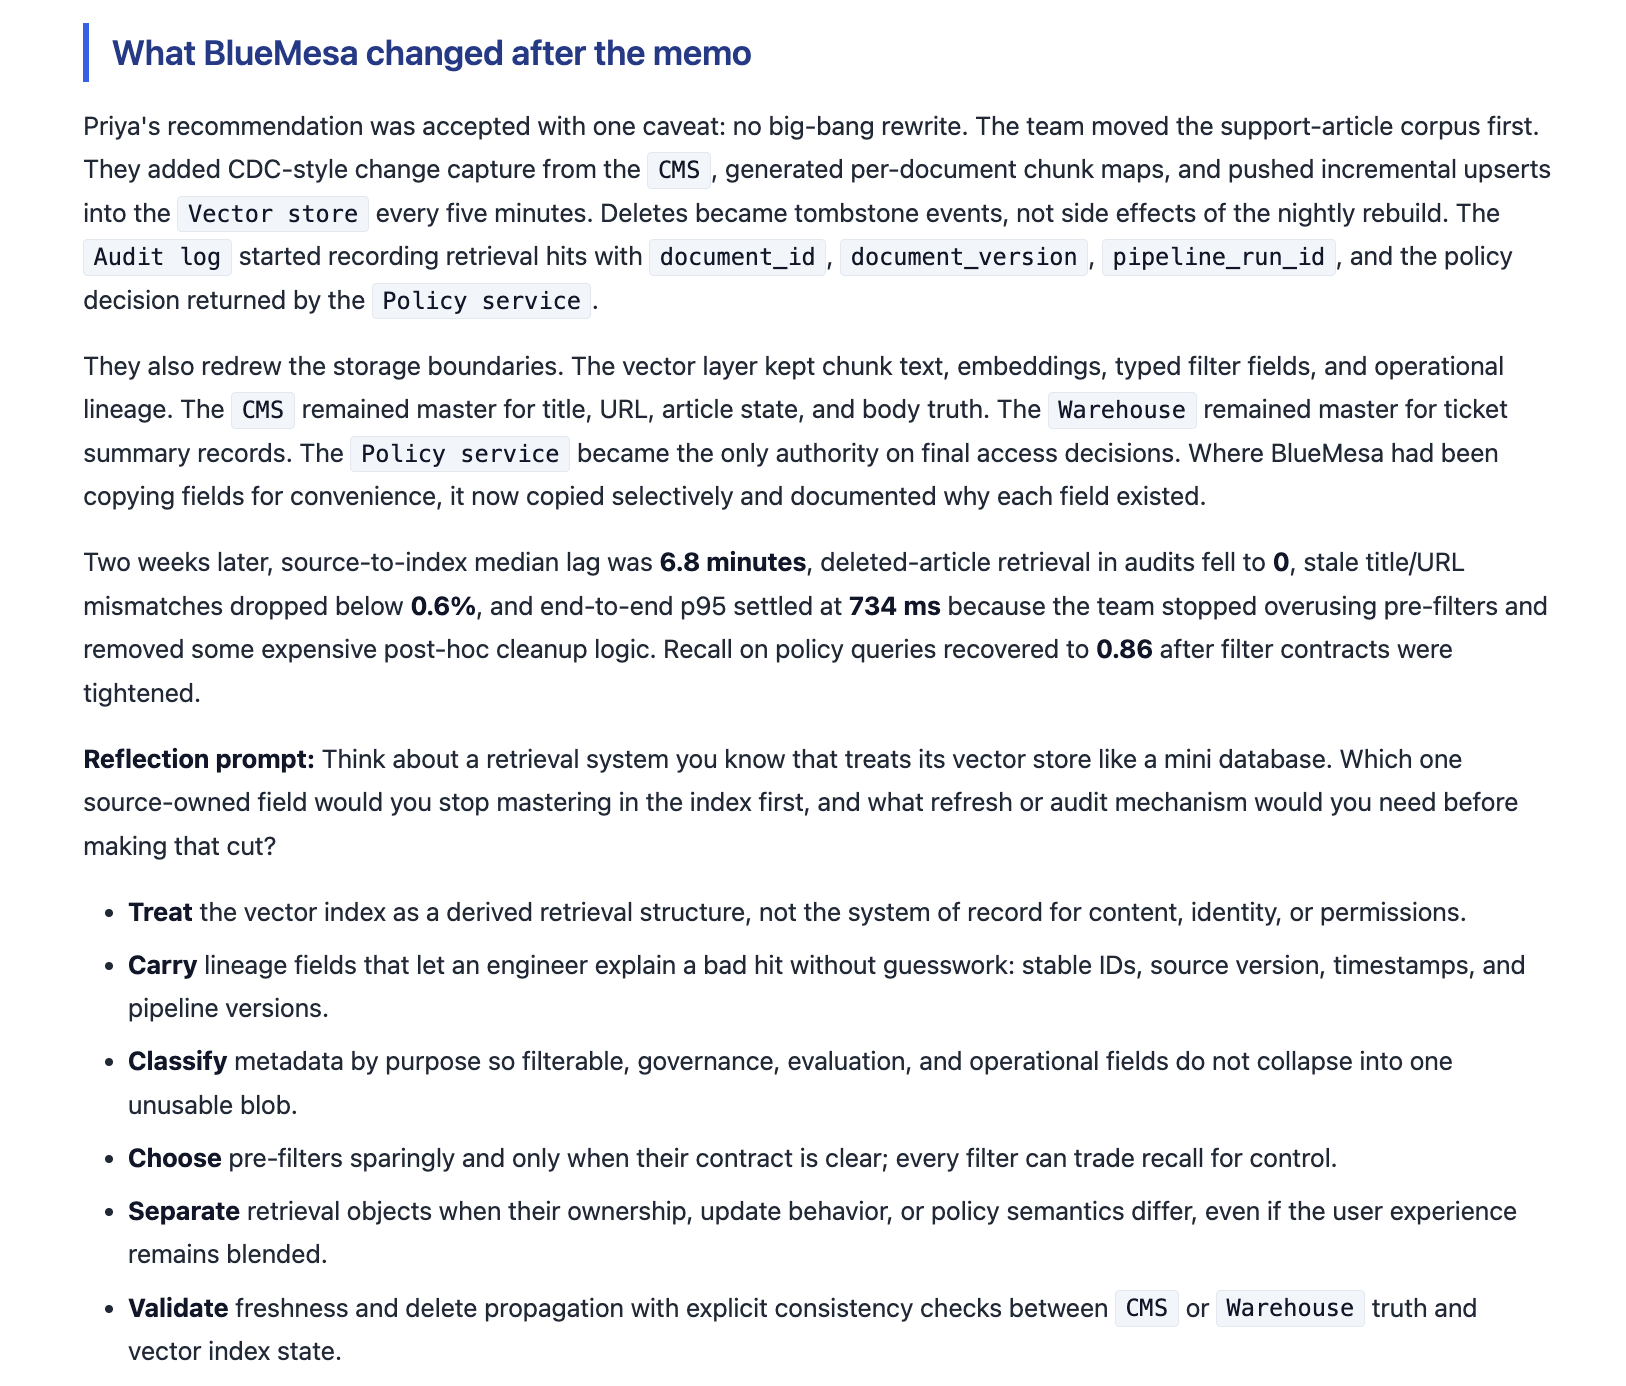
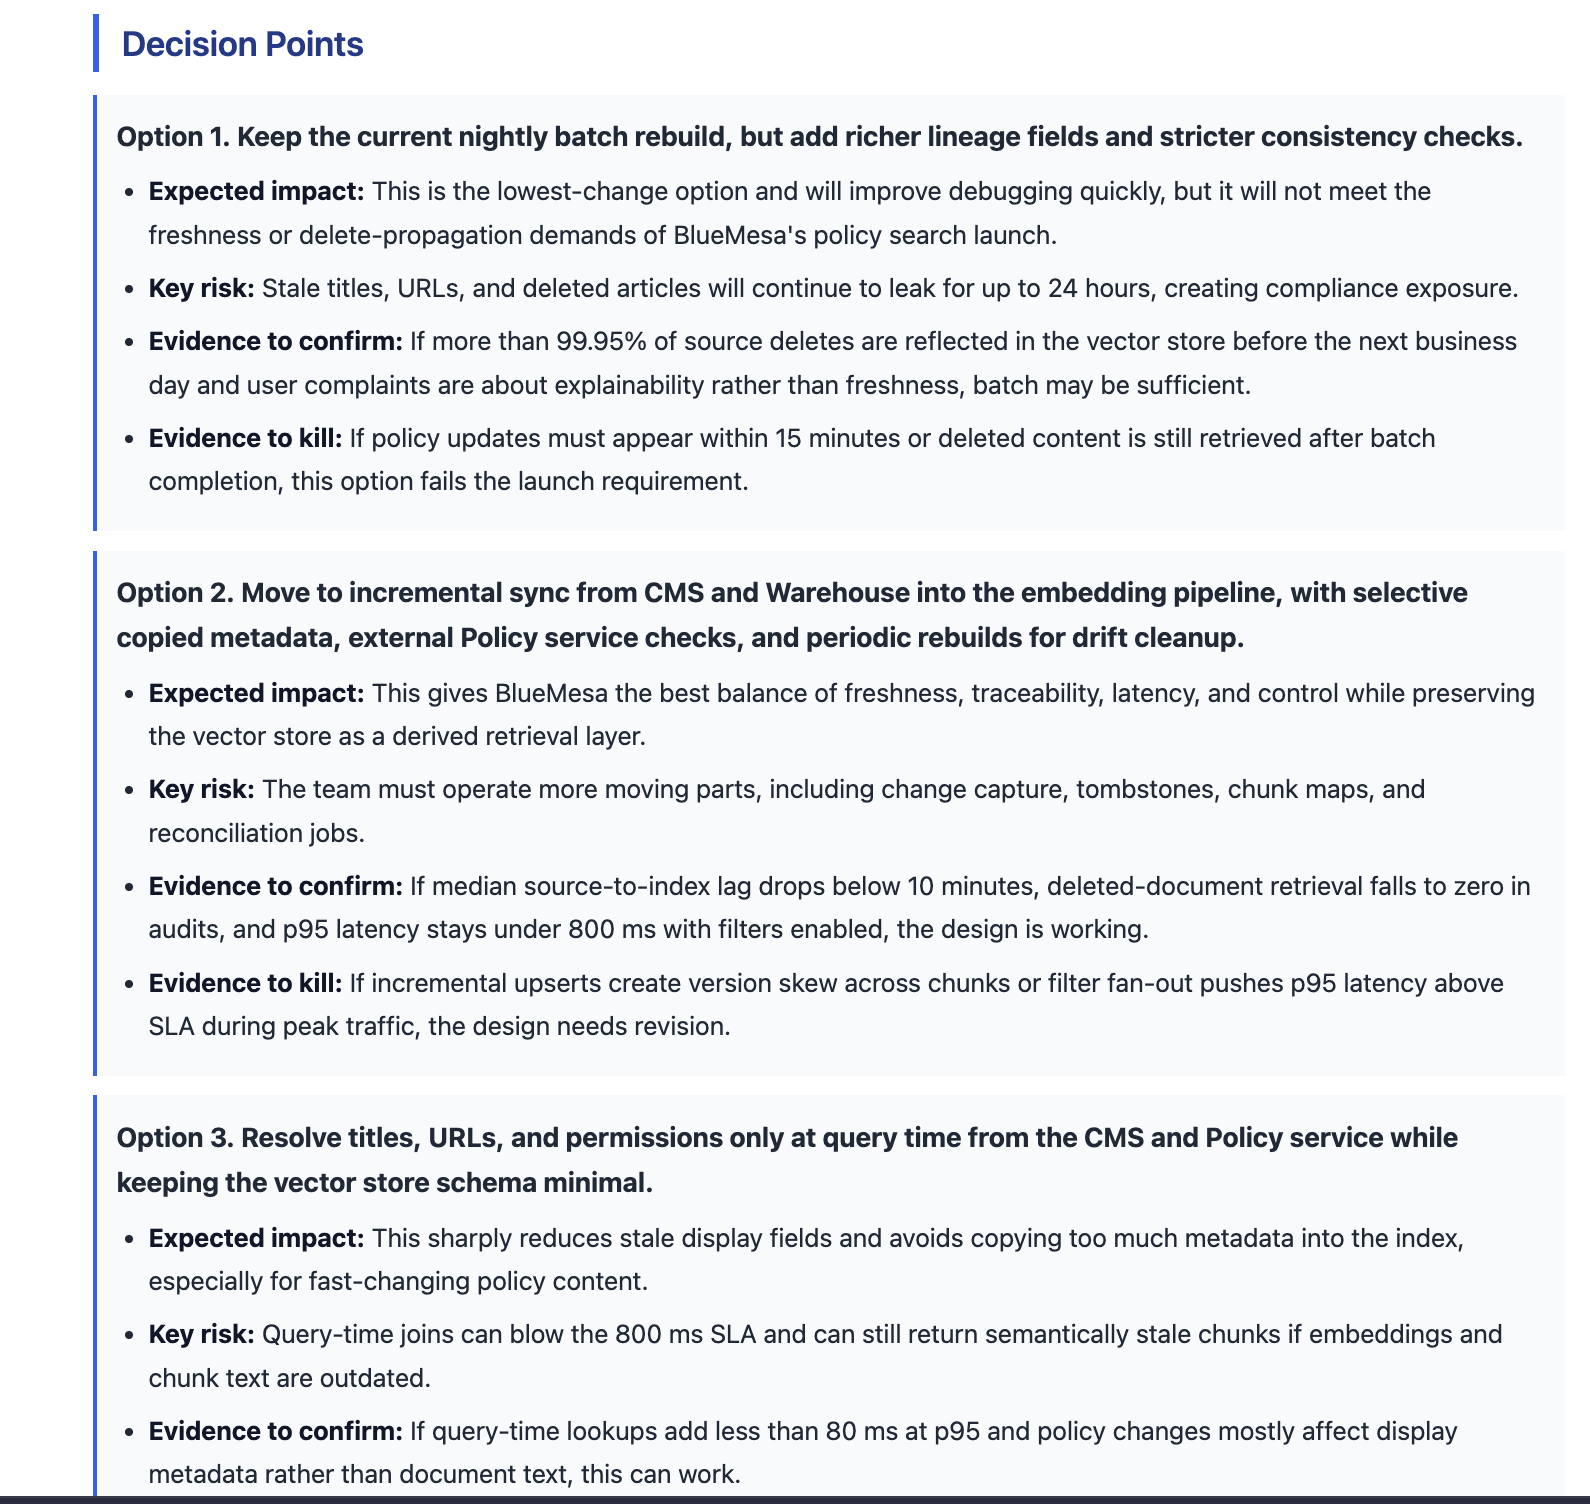
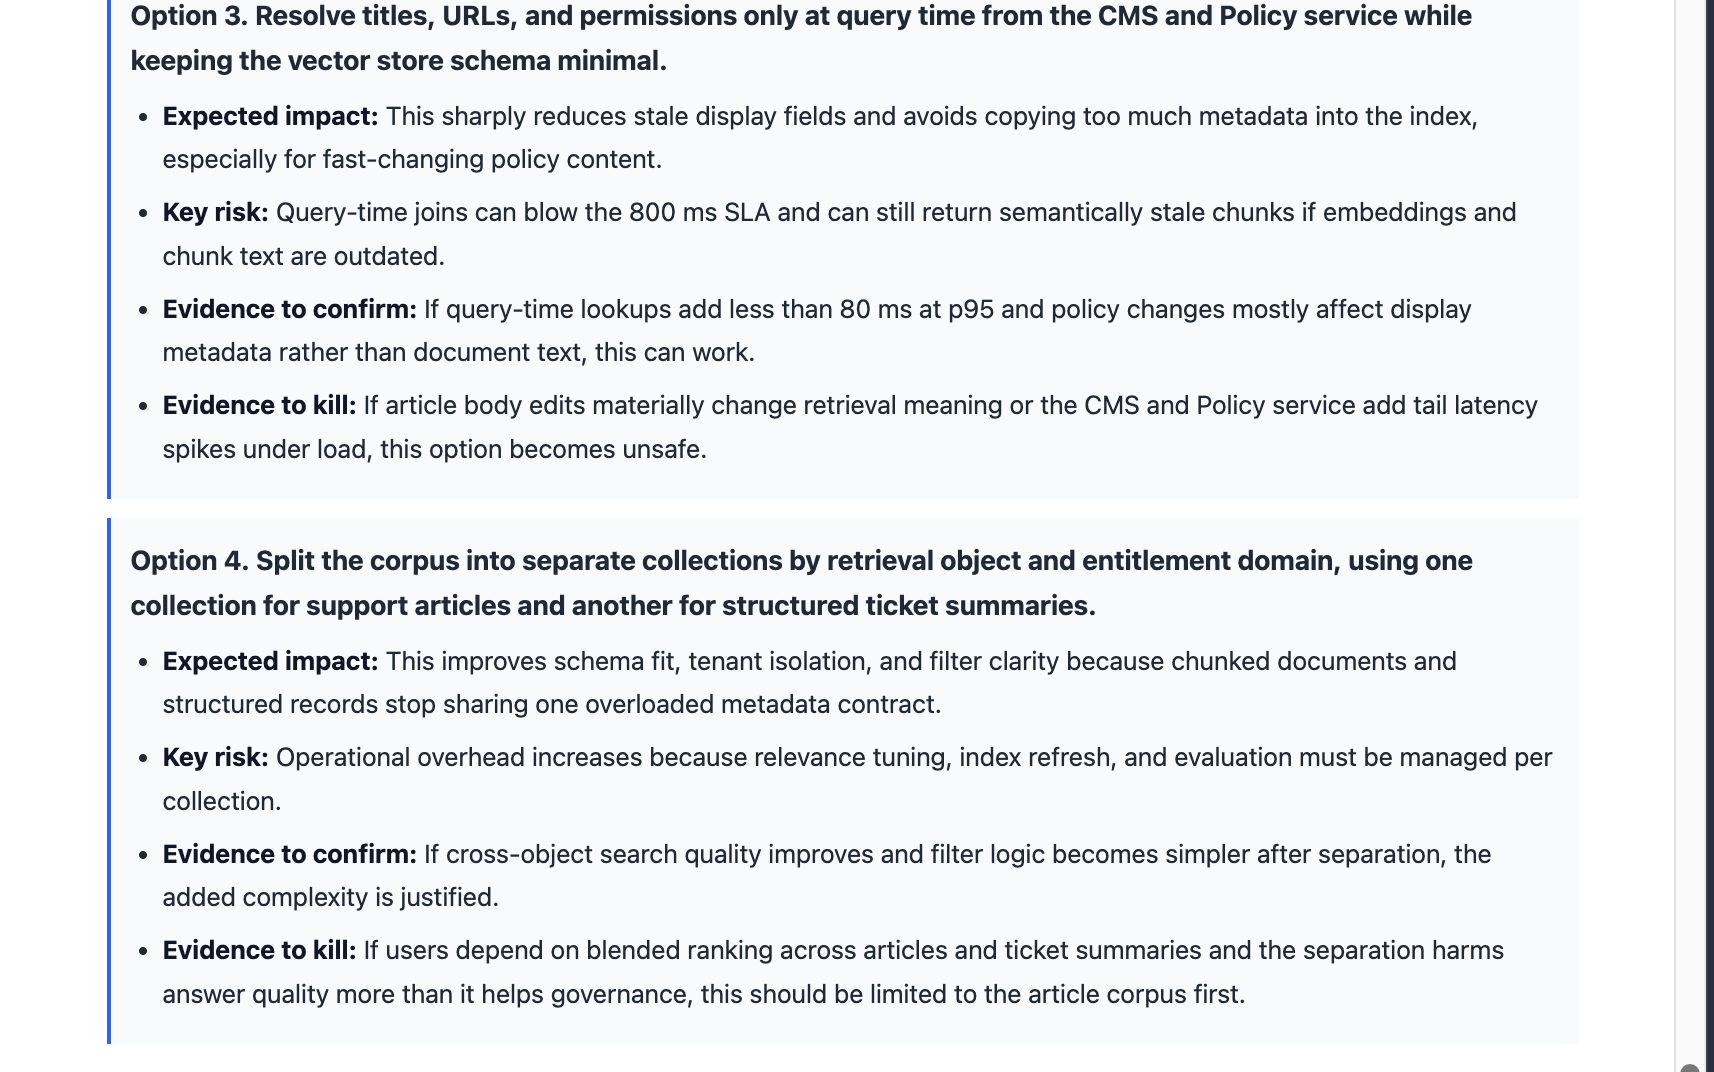
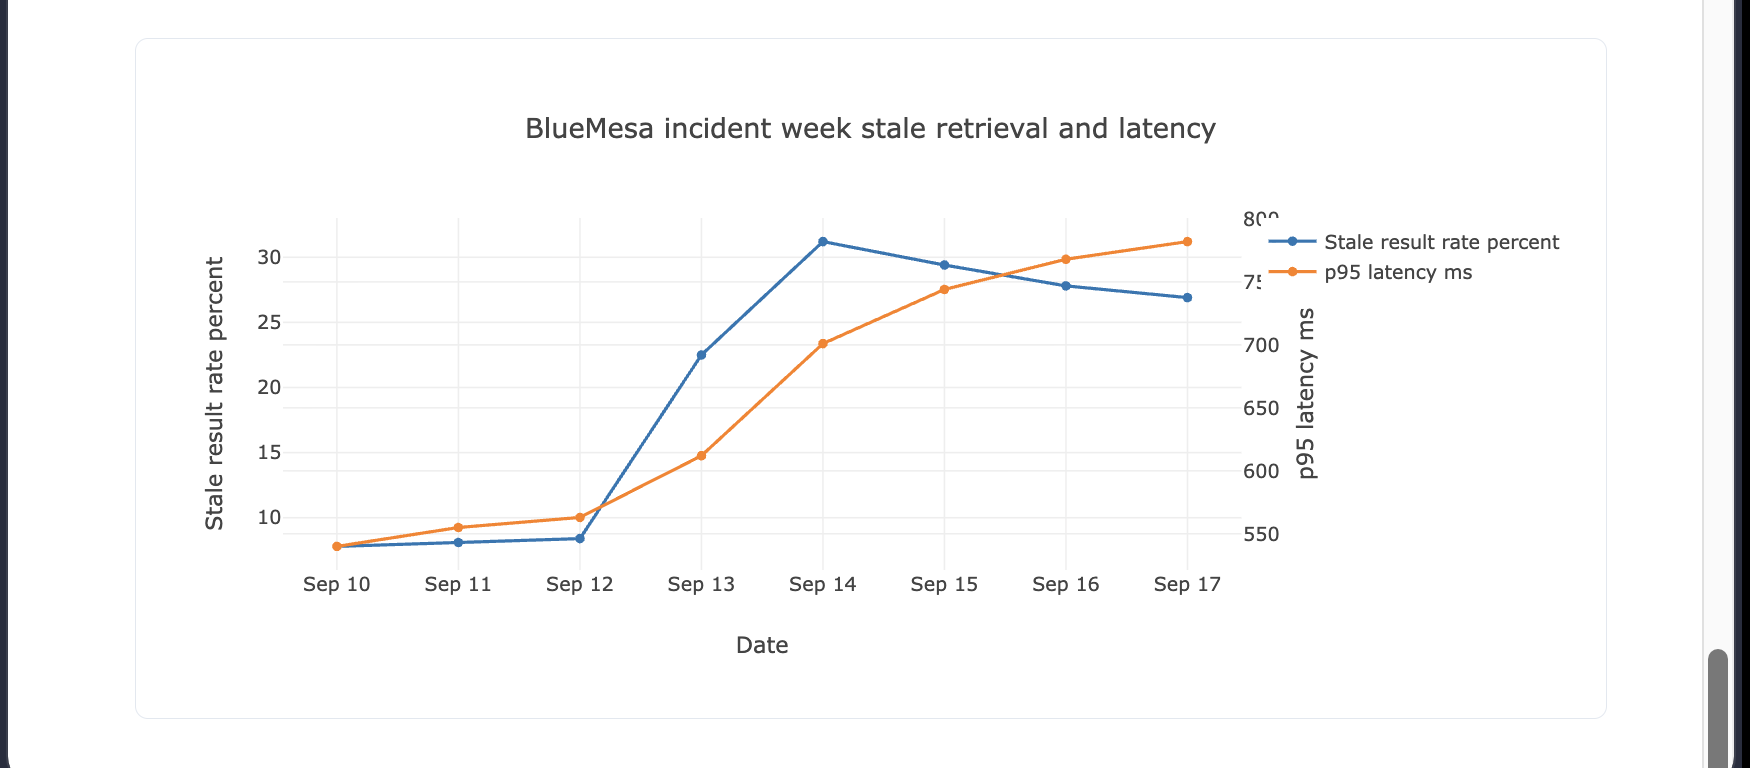


# What's Actually happening?

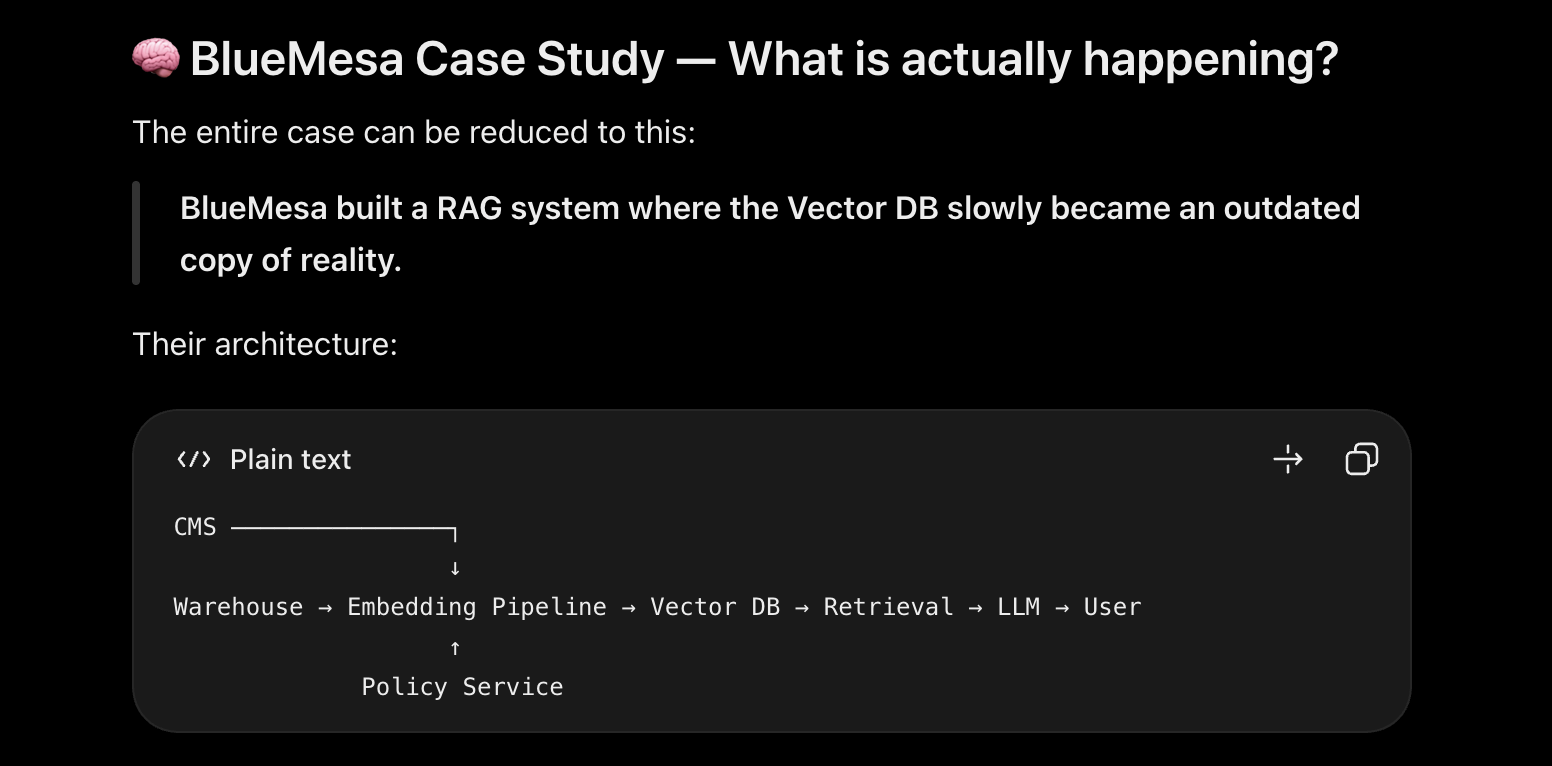
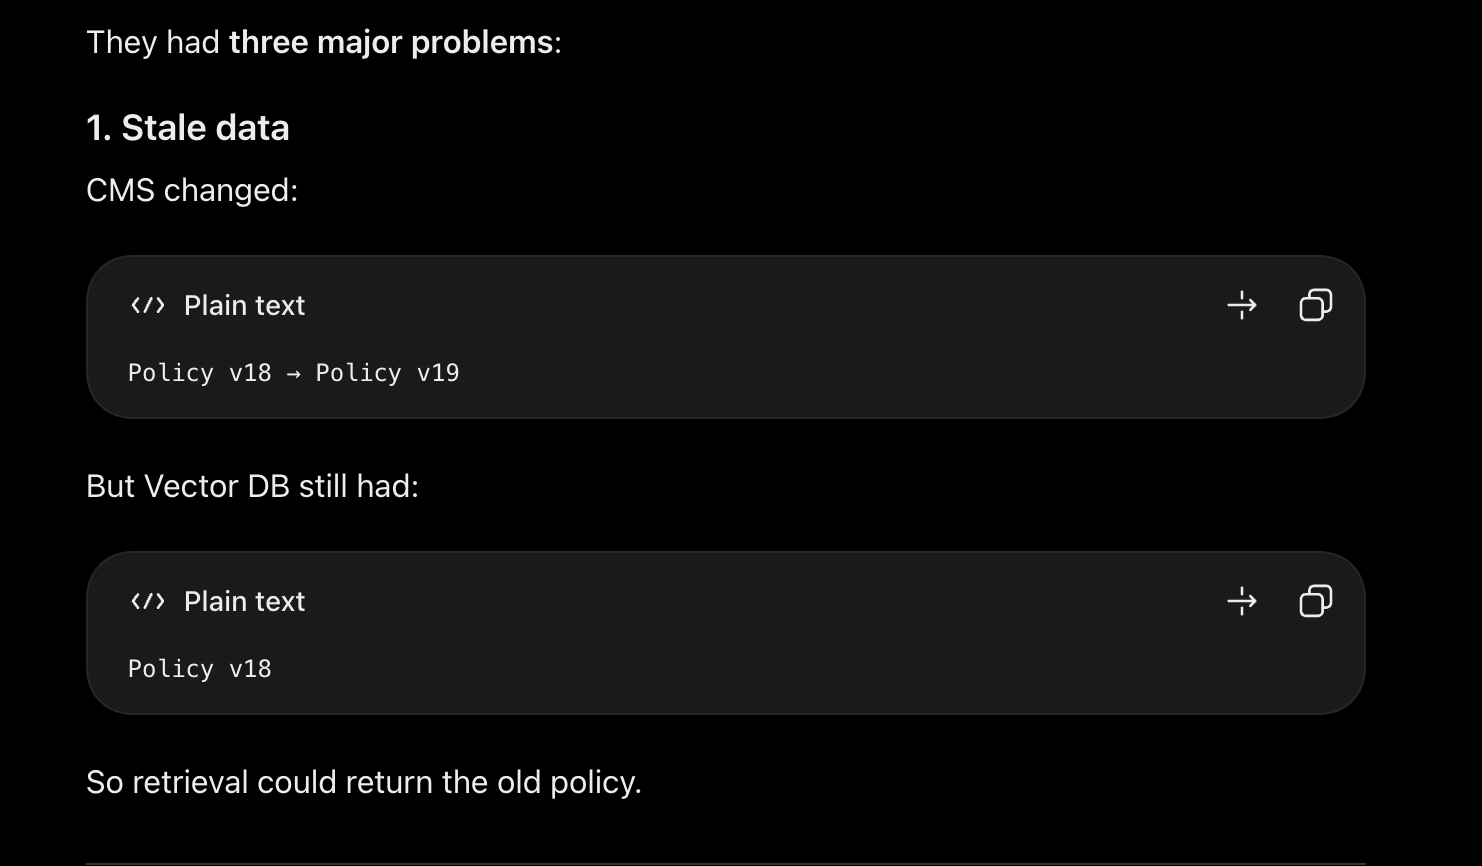
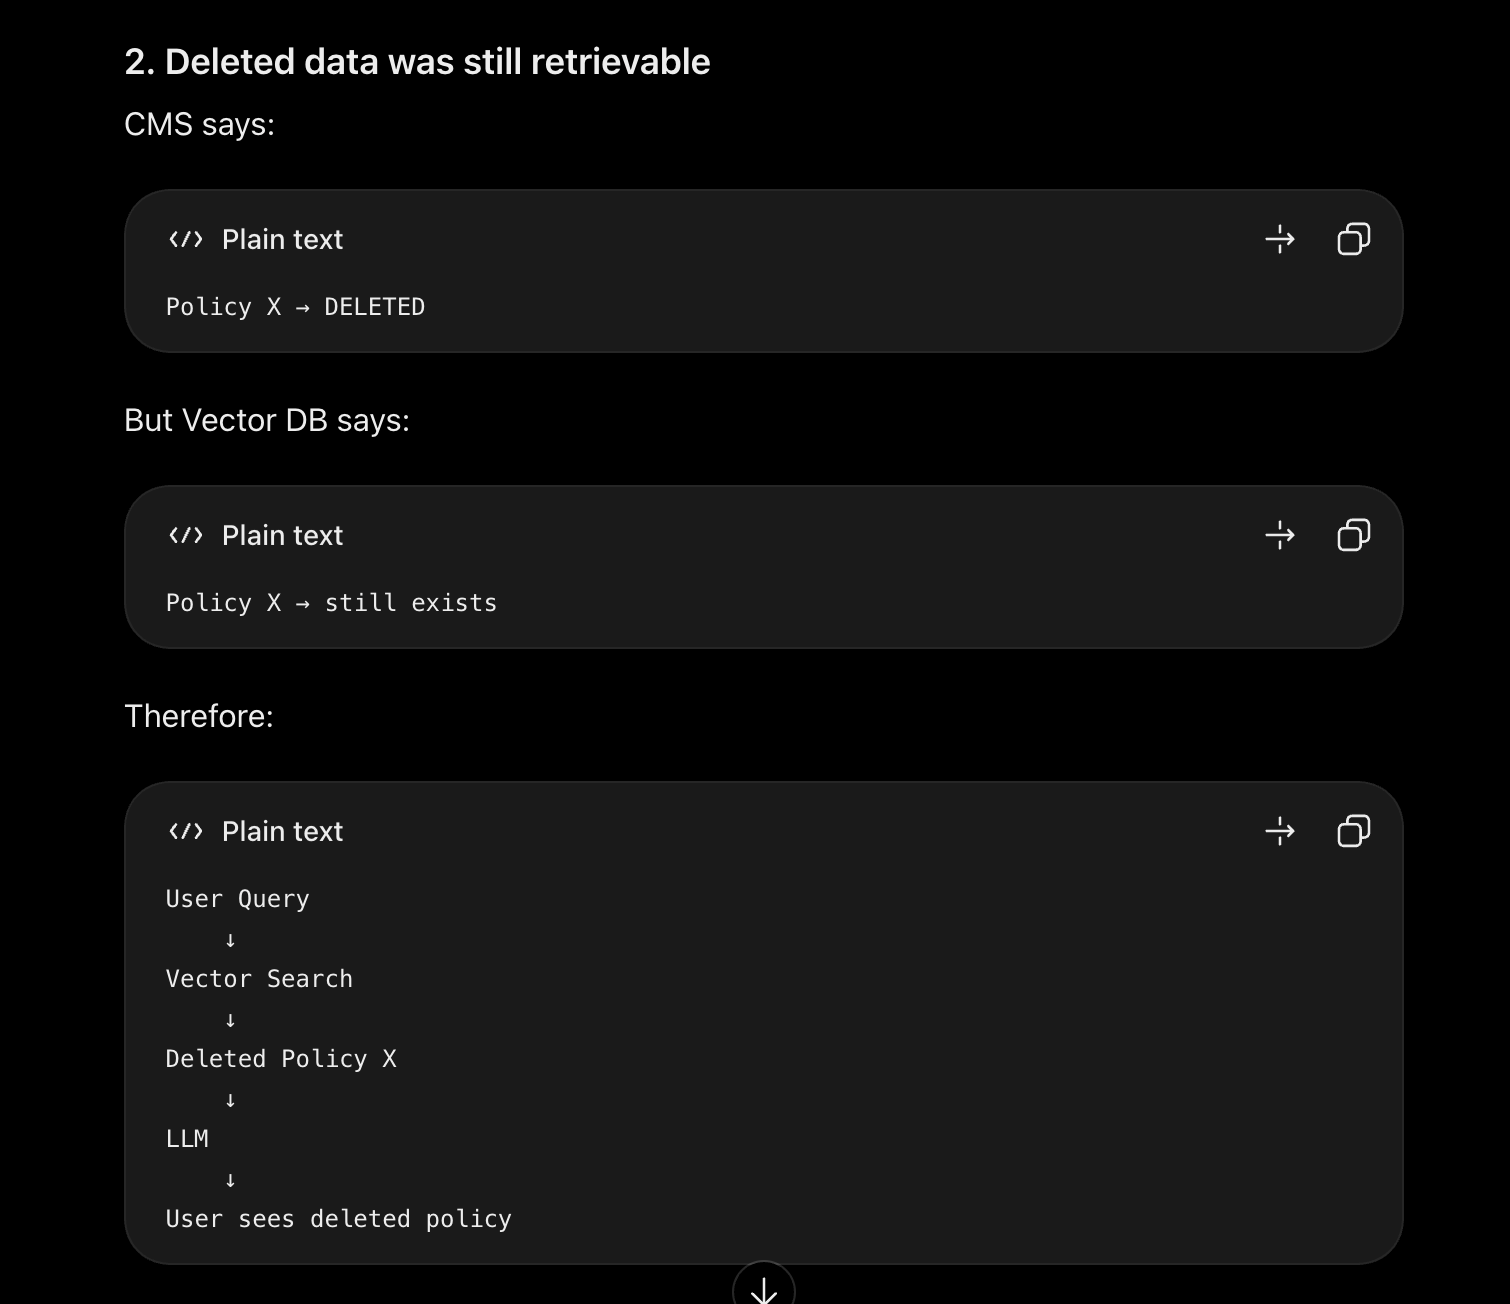
This is much more serious than a normal retrieval-quality problem.
It's a governance/security failure.
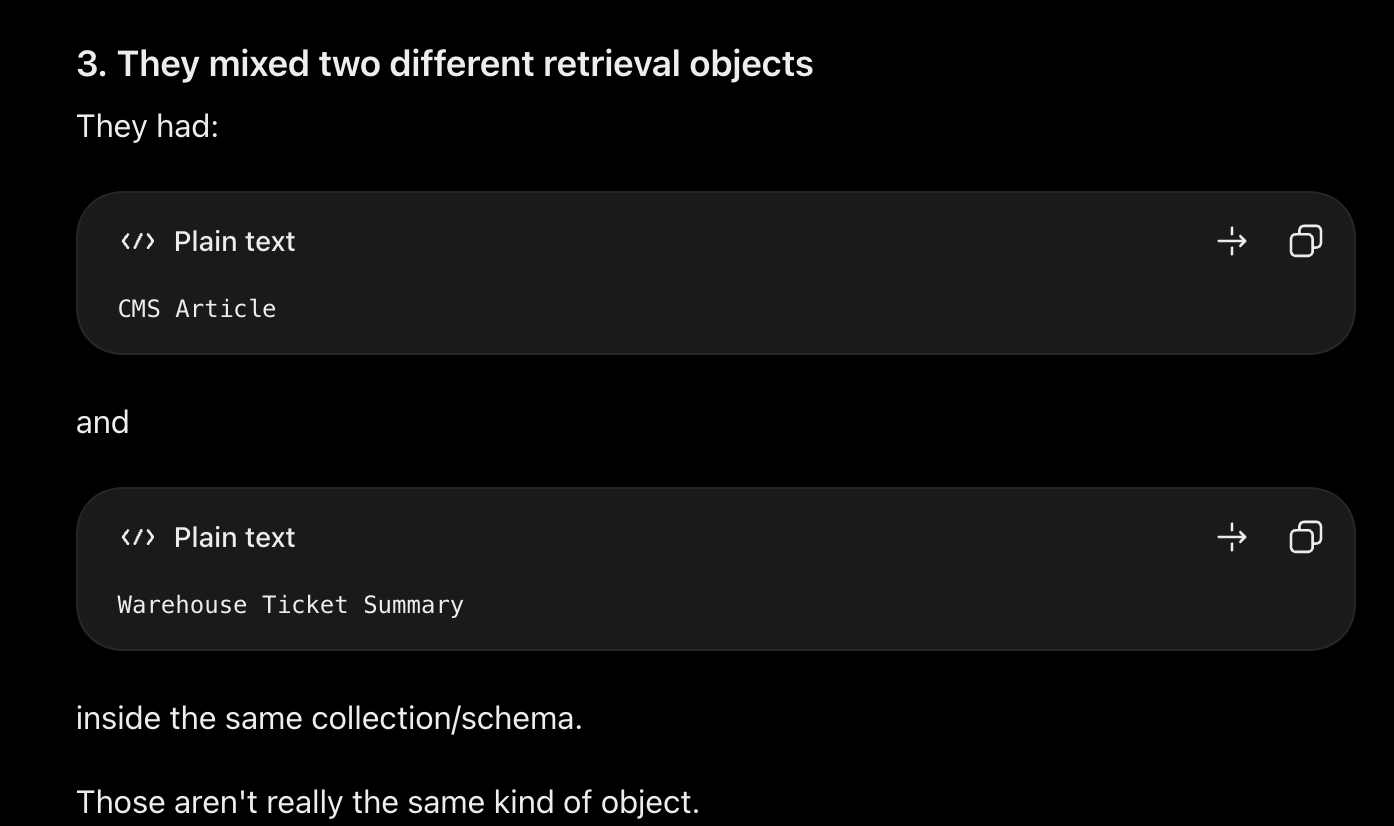
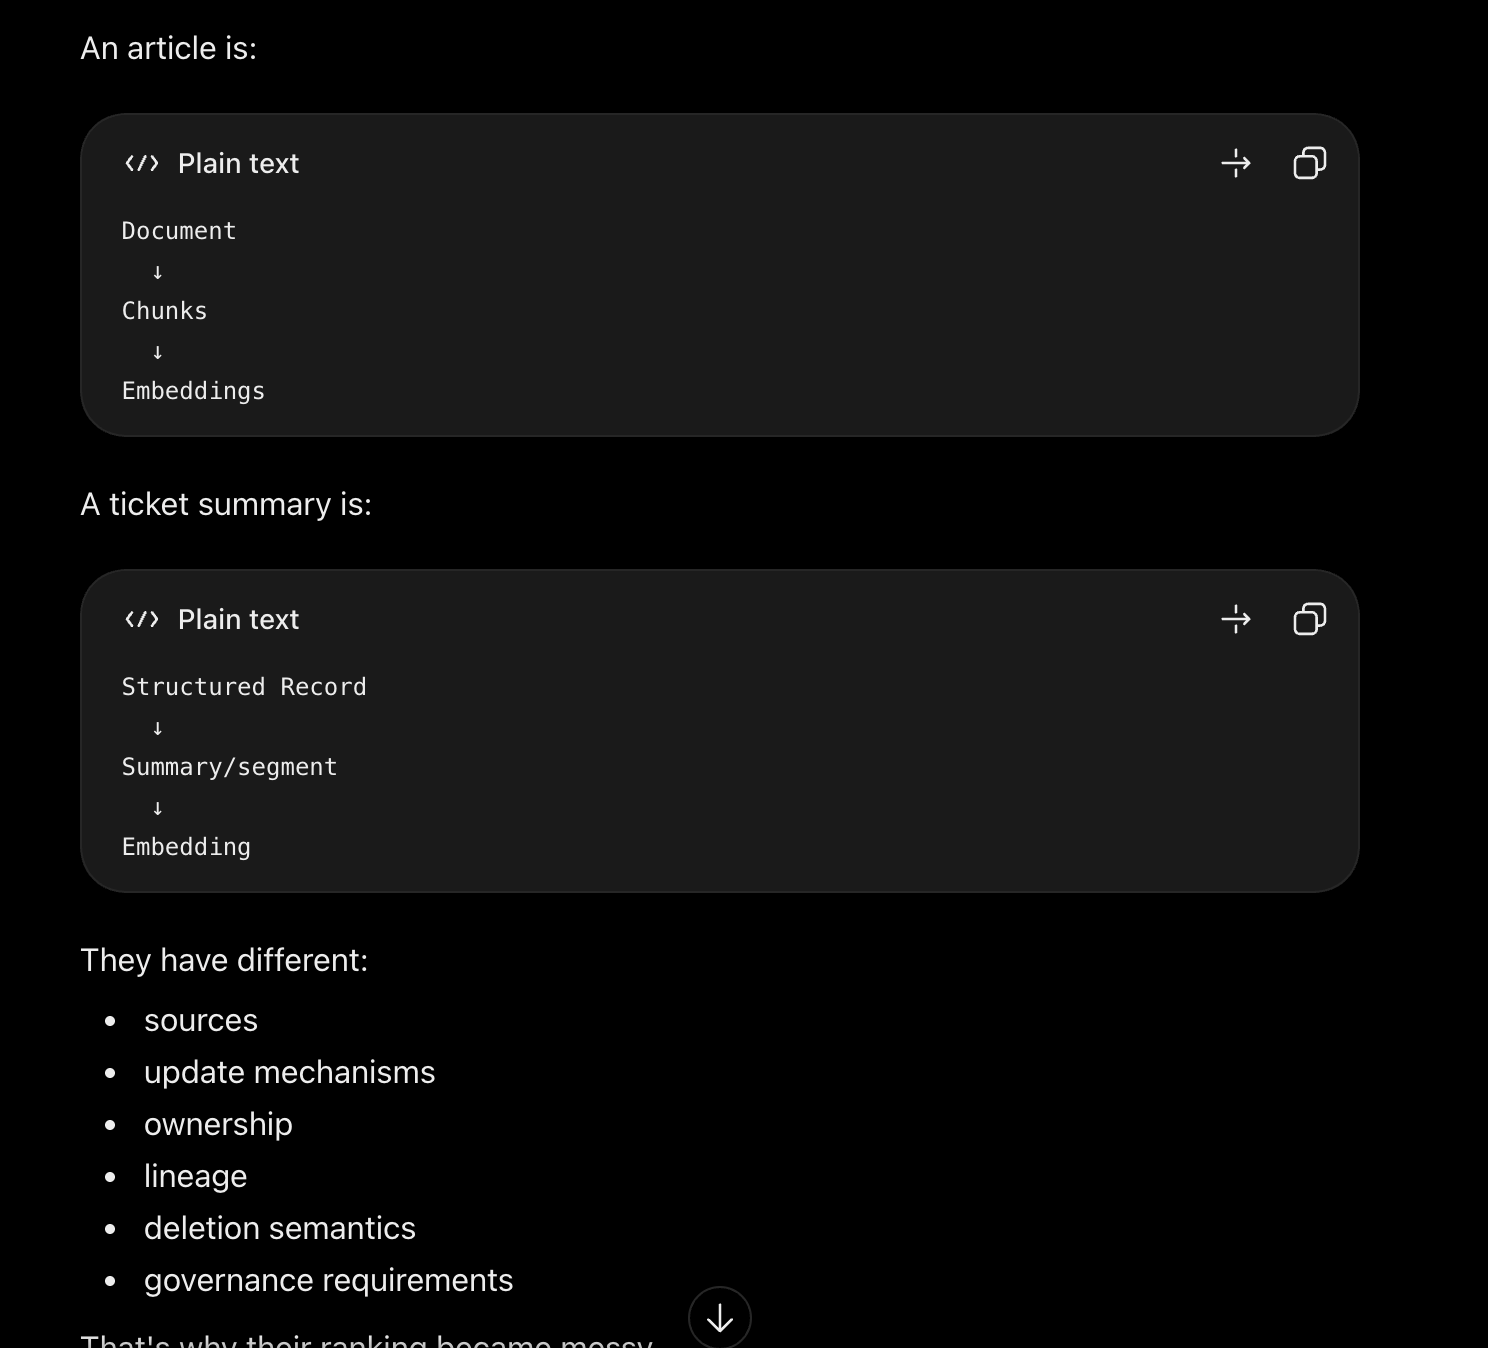
That's why their ranking became messy.


# 🔥 The most important concept in this case
This sentence from the case is basically something you should remember:
# The vector index is a derived retrieval structure, not the system of record.
<pre>.
Meaning:
CMS owns:
title
URL
article body
publication state
document version

Warehouse owns:
ticket records
ticket summaries
business data

Policy Service owns:
WHO IS ALLOWED TO SEE WHAT

Vector DB owns:
embedding
chunk
retrieval metadata
lineage

That's the boundary.</pre>



# 🗂️ Case Study: Keeping a Vector Index Fresh, Governed & Auditable

> **Core lesson:** Don't solve a synchronization problem entirely by adding query-time lookups.
> Instead, keep the vector index sufficiently fresh through **incremental synchronization**.

---

## 1. Why not just check the CMS on every request?

This is where the **782 ms** number becomes extremely important.

| Metric | Value |
|---|---|
| SLA (p95) | **800 ms** |
| Current system (p95) | **782 ms** |
| **Headroom** | 800 − 782 = **18 ms** |

Now imagine doing this for **every request**:

```
Vector DB
   ↓
CMS lookup
   ↓
Policy Service lookup
   ↓
maybe Warehouse lookup
```

With only **18 ms** of headroom, that could destroy the SLA.

---

## 2. The Four Options

### ❌ Option 1 — Nightly rebuild

```
CMS
 ↓
Every night
 ↓
Embedding
 ↓
Vector DB
```

**Problem:** Compliance says *updates must appear within 15 minutes*.
A nightly refresh obviously can't guarantee that → **Reject.**

---

### ❌ Option 3 — Everything at query time

```
Vector DB
 ↓
CMS
 ↓
Policy Service
 ↓
User
```

**Problem 1 — Latency:** Already at 782 / 800 ms. Only 18 ms left.

**Problem 2 — It doesn't fix stale content (the killer point):**
Querying the CMS doesn't magically fix an old embedding/chunk.

```
Old policy:  "Travel reimbursement = $500"
New policy:  "Travel reimbursement = $700"
```

If the old chunk remains embedded, correcting its URL at query time does **not** make its semantic content become $700.

→ **Reject as the primary solution.**

---

### ⚠️ Option 4 — Separate collections

```
Article Collection
       +
Ticket Collection
```

This is actually a **good idea**, because the objects are different.
But it doesn't solve the fundamental synchronization problem — you could still have:

```
Article Collection  →  STALE
Ticket Collection   →  STALE
```

→ Separation alone isn't enough.

---

### ✅ Option 2 — Incremental synchronization (the winner)

```
                  ┌───────────────┐
                  │      CMS      │
                  └───────┬───────┘
                          │
                     Change event
                          ↓
                  ┌───────────────┐
                  │   Embedding   │
                  │    Pipeline   │
                  └───────┬───────┘
                          │
                     upsert/delete
                          ↓
                  ┌───────────────┐
                  │   Vector DB   │
                  └───────┬───────┘
                          │
                       retrieve
                          ↓
                     Application
                          │
                          ↓
                  ┌───────────────┐
                  │ Policy Service│
                  └───────────────┘
```

**On update:**

```
CMS changed
   ↓
CDC / change capture
   ↓
Re-embed affected document
   ↓
Upsert new chunks
```

**On delete (delete propagation):**

```
CMS says DELETE
   ↓
Tombstone event
   ↓
Delete corresponding vectors
```

---

## 3. 🪦 What is a Tombstone?

Instead of the system silently forgetting that something existed:

```
document-123 → deleted
```

you record an **explicit deletion event/state**:

```
document_id = doc-123
deleted_at  = 2024-09-16T10:00
```

Then the retrieval pipeline knows: *"Don't let this thing come back."*

> 📌 From the case: *Deletes became tombstone events, not side effects of the nightly rebuild.*
>
> **Very important concept for my security project.**

---

## 4. 🔍 Metadata & Retrieval Observability

**Old schema** — horrible for production debugging:

```json
{
    "id": "...",
    "text": "...",
    "embedding": "...",
    "metadata_json": {...}
}
```

**Improved record** adds:

| Field | Answers the question… |
|---|---|
| `document_id` | Which document? |
| `document_version` | Which version? |
| `source_updated_at` | When did the source change? |
| `chunker_version` | How was it chunked? |
| `embedding_model` | Which embedding model? |
| `pipeline_run_id` | Which ingestion run? |
| `source_system` | Which system did it come from? |

Now if someone asks *"Why did the system return the wrong policy?"*, you can actually investigate.
**That's retrieval observability.**

---

## 5. 🚨 Connection to My Security Project

My original idea: **Don't blindly trust the LLM. Secure the retrieval/database layer itself.**
This case validates that philosophy.

**Naive pipeline:**

```
User → LLM → Retriever → Vector DB → LLM
```

You cannot assume *"the LLM will figure out whether this retrieved document is allowed."*

**Secure pipeline:**

```
                 ┌───────────────┐
                 │   Vector DB   │
                 └───────┬───────┘
                         ↓
                  Candidate docs
                         ↓
              ┌──────────────────┐
              │ Retrieval Checks │
              └────────┬─────────┘
                       ↓
              ┌──────────────────┐
              │ Governance/Auth  │
              │     Checks       │
              └────────┬─────────┘
                       ↓
                 Allowed docs
                       ↓
                      LLM
```

The database/retrieval layer has **its own rules**.

---

## 6. ⚠️ Relevance Filtering vs Governance Filtering

These are **NOT** the same thing.

| | Relevance filtering | Governance filtering |
|---|---|---|
| **Example fields** | `region = US`<br>`language = English`<br>`product = Travel` | `tenant_id = customer_123`<br>`access_group = support-readonly`<br>`sensitivity = public` |
| **Question it asks** | *Is this document relevant to the query?* | *Is this user actually allowed to retrieve this document?* |
| **Purpose** | Quality of results | Security / authorization |

> 💡 Probably **one of the most important concepts** for my security project.

---

## 7. 🏗️ The Case's Final Architecture

```
              SOURCE SYSTEMS
        ┌──────────┬────────────┐
        ↓          ↓
       CMS     Warehouse
        │          │
        └────┬─────┘
             ↓
     Incremental Pipeline
             ↓
        Vector Store
             ↓
      Retrieval / Ranking
             ↓
      ┌───────────────┐
      │ Policy Service│
      └───────┬───────┘
              ↓
        Authorized result
              ↓
             LLM
              ↓
            User
```

**The audit system records:**

- `document_id`
- `document_version`
- `pipeline_run_id`
- policy decision

→ If something goes wrong, you can **reconstruct what happened**.

---

## 8. 🧠 The 8 Principles to Take Away

*Don't memorize the BlueMesa names — understand these.*

### 1. Vector DB is not truth
```
Source system = truth
Vector DB     = derived retrieval representation
```

### 2. Freshness must be designed
Don't assume `source changed → vector magically changes`. You need:
```
change detection → reindex / update
```

### 3. Deletes are first-class events
```
DELETE ≠ ignore it
DELETE → propagate deletion
```

### 4. Lineage matters
Every retrieval result should answer:
- Where did this come from?
- Which version?
- Which pipeline?
- When was it indexed?

### 5. Relevance ≠ authorization
A document can be **highly relevant** *and* **completely unauthorized**.
Therefore relevance ranking **cannot** be your security mechanism.

### 6. Pre-filters have a tradeoff
More filtering can mean:
```
↑ control
↑ latency
↓ recall
```
So don't blindly apply every filter.

### 7. Different retrieval objects may deserve different schemas/collections
```
Documents ≠ Structured records
```

### 8. Query-time checks aren't free
Powerful for volatile information like **permissions**, but they cost **latency**.

---

## 9. 📈 Course Progression So Far

```
Embedding
   ↓
Similarity
   ↓
BM25 / Dense / Hybrid
   ↓
Normalization
   ↓
Vector Schema
   ↓
Metadata
   ↓
Pre/Post Filtering
   ↓
Source of Truth
   ↓
Freshness
   ↓
Deletes
   ↓
Governance
   ↓
Auditability
```

➡️ **Next step:** put these together into an actual **secure retrieval architecture**.